In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
data=pd.read_csv(r"C:\Users\Dell\Downloads\splice.data")

In [4]:
data.head()

,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGGTCTGTTCCAAGGGCCTTCGAGCCAGTCTG
0,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
1,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
2,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
3,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...
4,EI,CHPIGECA-DONOR-378,CAGACTGGGTGGACAACAAAACCTTCAGCGGTA...


In [5]:
#rename the columns
data.columns=["Class","ID","Sequence"]
data.head()

,Class,ID,Sequence
0,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
1,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
2,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
3,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...
4,EI,CHPIGECA-DONOR-378,CAGACTGGGTGGACAACAAAACCTTCAGCGGTA...


In [6]:
#shape
data.shape

(3189, 3)

In [7]:
#information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3189 entries, 0 to 3188
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Class     3189 non-null   str  
 1   ID        3189 non-null   str  
 2   Sequence  3189 non-null   str  
dtypes: str(3)
memory usage: 74.9 KB


In [8]:
#class distribution
data["Class"].value_counts()

Class
N     1655
IE     768
EI     766
Name: count, dtype: int64

In [9]:
#missing values
data.isnull().sum()

Class       0
ID          0
Sequence    0
dtype: int64

In [10]:
data.head()

,Class,ID,Sequence
0,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
1,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
2,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
3,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...
4,EI,CHPIGECA-DONOR-378,CAGACTGGGTGGACAACAAAACCTTCAGCGGTA...


In [11]:
data.to_csv("splice_clean.csv",index=False)

In [12]:
data["Sequence"].iloc[0]

'               AGACCCGCCGGGAGGCGGAGGACCTGCAGGGTGAGCCCCACCGCCCCTCCGTGCCCCCGC'

In [13]:
data["Sequence"]= data["Sequence"].str.replace(" ","",regex=False)

In [14]:
data["Sequence"].str.len().value_counts()

Sequence
60    3189
Name: count, dtype: int64

In [15]:
characters = set("".join(data["Sequence"]))
print(characters)

{'A', 'S', 'G', 'R', 'C', 'D', 'T', 'N'}


In [16]:
#one hot encoding
encoding = {
    'A': [1, 0, 0, 0],
    'C': [0, 1, 0, 0],
    'G': [0, 0, 1, 0],
    'T': [0, 0, 0, 1],

    'N': [0.25, 0.25, 0.25, 0.25],   # Any base
    'R': [0.5, 0, 0.5, 0],           # A or G
    'S': [0, 0.5, 0.5, 0],           # C or G
    'D': [1/3, 0, 1/3, 1/3]          # A or G or T
}

In [17]:
def encode_sequence(sequence):
    return[encoding[base] for base in sequence]

In [18]:
X=data["Sequence"].apply(encode_sequence)
X=np.array(X.tolist())
print(X.shape)


(3189, 60, 4)


In [19]:
#label encoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(data["Class"])

print(label_encoder.classes_)
print(y[:10])

['EI' 'IE' 'N']
[0 0 0 0 0 0 0 0 0 0]


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2551, 60, 4)
Testing: (638, 60, 4)


In [31]:
!pip install tensorflow


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [33]:
#cnn model
model = Sequential([
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(60, 4)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

C:\Users\Dell\Documents\splice.DNA\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
#compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 58, 64)              │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 29, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 27, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 13, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1664)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         106,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,291 (516.76 KB)

 Trainable params: 132,291 (516.76 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#train the model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.6691 - loss: 0.7616 - val_accuracy: 0.8982 - val_loss: 0.3540
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8873 - loss: 0.3217 - val_accuracy: 0.9335 - val_loss: 0.2015
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9324 - loss: 0.2096 - val_accuracy: 0.9452 - val_loss: 0.1549
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9520 - loss: 0.1518 - val_accuracy: 0.9569 - val_loss: 0.1248
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9593 - loss: 0.1206 - val_accuracy: 0.9628 - val_loss: 0.1193
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9725 - loss: 0.0982 - val_accuracy: 0.9609 - val_loss: 0.1200
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9765 - loss: 0.0861 - val_accuracy: 0.9569 - val_loss: 0.1247
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9770 - loss: 0.0750 - val_accuracy: 0.9569 - v

In [37]:
#evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9639 - loss: 0.1826
Test Accuracy: 0.9639498591423035


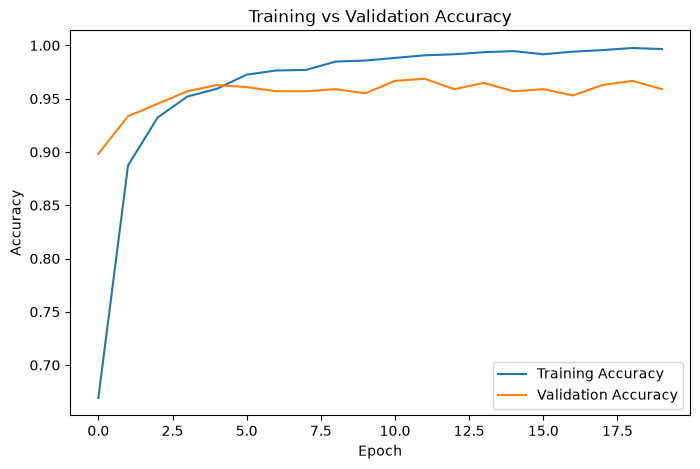

In [38]:
#accuracy plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

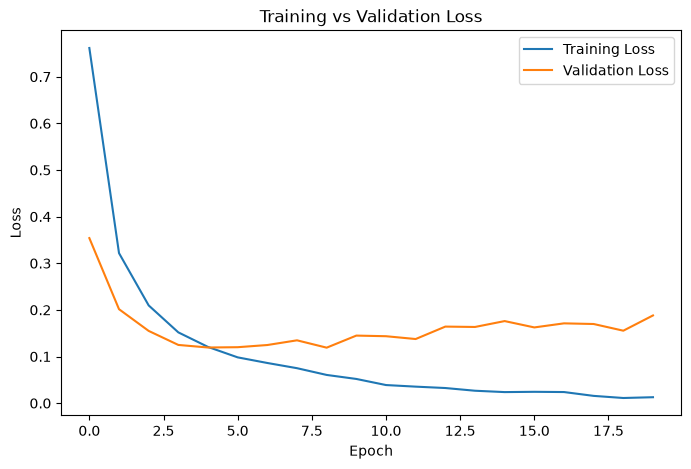

In [39]:
#loss plot
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [40]:
predictions = model.predict(X_test)

predicted_classes = predictions.argmax(axis=1)

print(predicted_classes[:10])

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
[0 1 2 2 2 2 1 2 2 0]


In [41]:
model.save("dna_sequence_cnn.keras")

In [42]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9639 - loss: 0.1826
Test Loss: 0.18263362348079681
Test Accuracy: 0.9639498591423035


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


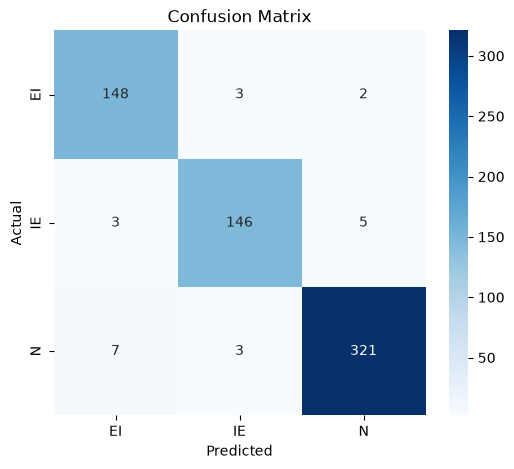

In [43]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(X_test)
predicted_classes = predictions.argmax(axis=1)

cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predicted_classes,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

          EI       0.94      0.97      0.95       153
          IE       0.96      0.95      0.95       154
           N       0.98      0.97      0.97       331

    accuracy                           0.96       638
   macro avg       0.96      0.96      0.96       638
weighted avg       0.96      0.96      0.96       638

